# Modeling COVID 19

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import exp
import matplotlib as mpl

We will also use SciPy’s numerical routine odeint for solving differential
equations.

In [2]:
from scipy.integrate import odeint

This routine calls into compiled code from the FORTRAN library odepack.

## The SIR Model

In the version of the SIR model we will analyze there are four states.

All individuals in the population are assumed to be in one of these four states.

The states are: susceptible (S), exposed (E), infected (I) and removed ®.

Comments:

- Those in state R have been infected and either recovered or died.  
- Those who have recovered are assumed to have acquired immunity.  
- Those in the exposed group are not yet infectious.  

### Time Path

The flow across states follows the path $ S \to E \to I \to R $.

All individuals in the population are eventually infected when
the transmission rate is positive and $ i(0) > 0 $.

The interest is primarily in

- the number of infections at a given time (which determines whether or not the health care system is overwhelmed) and  
- how long the caseload can be deferred (hopefully until a vaccine arrives)  


Using lower case letters for the fraction of the population in each state, the
dynamics are


<a id='equation-sir-system'></a>
$$
\begin{aligned}
     \dot s(t)  & = - \beta(t) \, s(t) \,  i(t)
     \\
     \dot e(t)  & = \beta(t) \,  s(t) \,  i(t)  - σ e(t)
     \\
     \dot i(t)  & = σ e(t)  - γ i(t)
\end{aligned} \tag{2.1}
$$

In these equations,

- $ \beta(t) $ is called the *transmission rate* (the rate at which individuals bump into others and expose them to the virus).  
- $ \sigma $ is called the *infection rate* (the rate at which those who are exposed become infected)  
- $ \gamma $ is called the *recovery rate* (the rate at which infected people recover or die).  
- the dot symbol $ \dot y $ represents the time derivative $ dy/dt $.  


We do not need to model the fraction $ r $ of the population in state $ R $ separately because the states form a partition.

In particular, the “removed” fraction of the population is $ r = 1 - s - e - i $.

We will also track $ c = i + r $, which is the cumulative caseload
(i.e., all those who have or have had the infection).

The system [(2.1)](#equation-sir-system) can be written in vector form as


<a id='equation-dfcv'></a>
$$
\dot x = F(x, t),  \qquad x := (s, e, i) \tag{2.2}
$$

for suitable definition of $ F $ (see the code below).

### Parameters

Both $ \sigma $ and $ \gamma $ are thought of as fixed, biologically determined parameters.

As in Atkeson’s note, we set

- $ \sigma = 1/5.2 $ to reflect an average incubation period of 5.2 days.  
- $ \gamma = 1/18 $ to match an average illness duration of 18 days.  


The transmission rate is modeled as

- $ \beta(t) := R(t) \gamma $ where $ R(t) $ is the *effective reproduction number* at time $ t $.  


(The notation is slightly confusing, since $ R(t) $ is different to
$ R $, the symbol that represents the removed state.)

## Implementation

First we set the population size to match the US.

Next we fix parameters as described above.

In [3]:
# 中国总人口
pop_size = 1.4e9
# 感染率
σ = 1 / 5.2
# 康复率
γ = 1 / 18

Now we construct a function that represents $ F $ in [(2.2)](#equation-dfcv)

In [4]:
def F(x, t, R0=1.6):
    s, e, i = x

    # 传播率，R0为有效传播率
    β = R0(t) * γ if callable(R0) else R0 * γ
    # 暴露感染率
    ne = β * s * i
    # 各人群导数
    ds = -ne
    de = ne - σ * e
    di = σ * e - γ * i

    return ds, de, di

Note that `R0` can be either constant or a given function of time.

The initial conditions are set to

In [5]:
# initial conditions of s, e, i
i_0 = 1e-7
e_0 = 4 * i_0
s_0 = 1 - i_0 - e_0

In vector form the initial condition is

In [6]:
x_0 = s_0, e_0, i_0

We solve for the time path numerically using odeint, at a sequence of dates
`t_vec`.

In [7]:
def get_cases(R0, t_vec, x_init=x_0):

    G = lambda x, t: F(x, t, R0)
    s_cases, e_cases, i_cases = odeint(G, x_init, t_vec).transpose()

    # 累计病例
    c_cases = 1 - s_cases - e_cases
    return i_cases, c_cases

## Experiments

Let’s run some experiments using this code.

The time period we investigate will be 550 days, or around 18 months:

In [8]:
t_length = 550
grid_size = 1000
t_vec = np.linspace(0, t_length, grid_size)

### Experiment 1: Constant R0 Case

Let’s start with the case where `R0` is constant.

We calculate the time path of infected people under different assumptions for `R0`:

In [9]:
# 选取有效传播率，1.6～3中的6个
R0_vals = np.linspace(1.6, 3.0, 6)
labels = [f'$R0 = {r:.2f}$' for r in R0_vals]
# 当前病例、累计病例
i_cases, c_cases = [], []

for r in R0_vals:
    # 求解
    i_case, c_case = get_cases(r, t_vec)
    i_cases.append(i_case)
    c_cases.append(c_case)

Here’s some code to plot the time paths.

In [10]:
def plot_cases(cases, labels, times=t_vec, title=''):

    fig, ax = plt.subplots()
    for case, label in zip(cases, labels):
        ax.plot(times, case, label=label)
    ax.legend(loc='upper left')
    ax.set(xlabel='天', ylabel='病例（比例）', title=title)
    plt.show()

Let’s plot current cases as a fraction of the population.

In [11]:
from matplotlib import font_manager

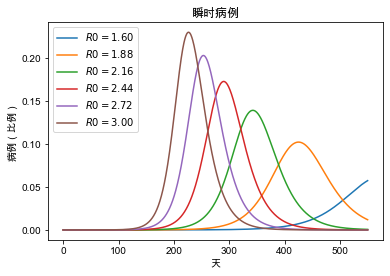

In [12]:
plt.rcParams['font.family'] = ['Arial Unicode MS']

plot_cases(i_cases, labels, title='瞬时病例')

As expected, lower effective transmission rates defer the peak of infections.

They also lead to a lower peak in current cases.

Here are cumulative cases, as a fraction of population:

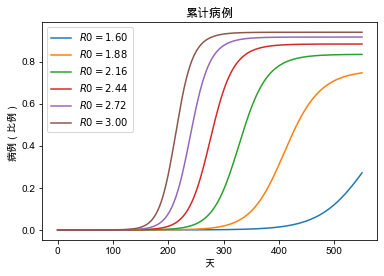

In [13]:
plot_cases(c_cases, labels, title='累计病例')

### Experiment 2: Changing Mitigation

Let’s look at a scenario where mitigation (e.g., social distancing) is
successively imposed.

Here’s a specification for `R0` as a function of time.

In [14]:
# 社交距离
η = 1
# R0 范围
r0, r_bar = 3, 1.6


def R0_mitigating(t, η=η, r0=r0, r_bar=r_bar):
    R0 = r0 * exp(-η * t) + (1 - exp(-η * t)) * r_bar
    return R0

The idea is that `R0` starts off at 3 and falls to 1.6.

This is due to progressive adoption of stricter mitigation measures.

The parameter `η` controls the rate, or the speed at which restrictions are
imposed.

We consider several different rates:

In [15]:
η_vals = 1/5, 1/10, 1/20, 1/50, 1/100
labels = [fr'$\eta = {η:.2f}$' for η in η_vals]

This is what the time path of `R0` looks like at these alternative rates:

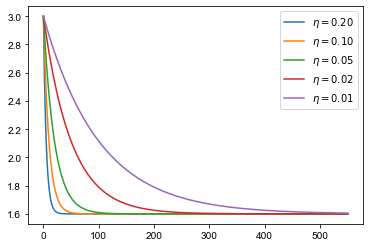

In [16]:
fig, ax = plt.subplots()

for η, label in zip(η_vals, labels):
    ax.plot(t_vec, R0_mitigating(t_vec, η=η), label=label)

ax.legend()
plt.show()

Let’s calculate the time path of infected people:

In [17]:
# 当前病例、累计病例
i_cases, c_cases = [], []

for η in η_vals:
    R0 = lambda t: R0_mitigating(t, η=η)
    i_case, c_case = get_cases(R0, t_vec)
    i_cases.append(i_case)
    c_cases.append(c_case)

These are current cases under the different scenarios:

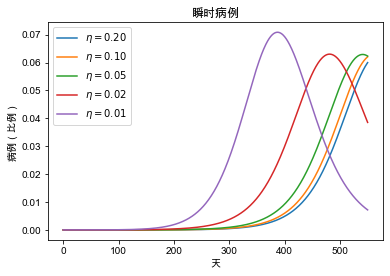

In [18]:
plot_cases(i_cases, labels, title='瞬时病例')

Here are cumulative cases, as a fraction of population:

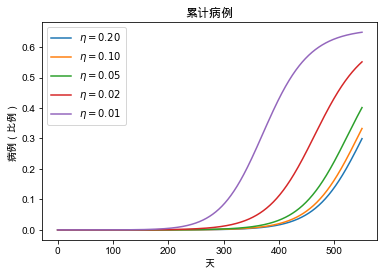

In [19]:
plot_cases(c_cases, labels, title='累计病例')

## Ending Lockdown

The following replicates [additional results](https://drive.google.com/file/d/1uS7n-7zq5gfSgrL3S0HByExmpq4Bn3oh/view) by Andrew Atkeson on the timing of lifting lockdown.

Consider these two mitigation scenarios:

1. $ R_t = 0.5 $ for 30 days and then $ R_t = 2 $ for the remaining 17 months. This corresponds to lifting lockdown in 30 days.  
1. $ R_t = 0.5 $ for 120 days and then $ R_t = 2 $ for the remaining 14 months. This corresponds to lifting lockdown in 4 months.  


The parameters considered here start the model with 25,000 active infections
and 75,000 agents already exposed to the virus and thus soon to be contagious.

In [20]:
# initial conditions
i_0 = 25_000 / pop_size
e_0 = 75_000 / pop_size
s_0 = 1 - i_0 - e_0
x_0 = s_0, e_0, i_0

Let’s calculate the paths:

In [21]:
R0_cases = (lambda t: 0.5 if t < 30 else 2,
            lambda t: 0.5 if t < 120 else 2)

labels = [f'scenario {i}' for i in (1, 2)]

i_cases, c_cases = [], []

for R0 in R0_cases:
    i_case, c_case = get_cases(R0, t_vec, x_init=x_0)
    i_cases.append(i_case)
    c_cases.append(c_case)

Here is the number of active infections:

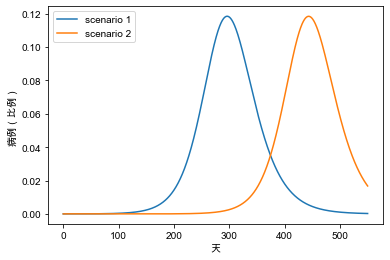

In [22]:
plot_cases(i_cases, labels)

What kind of mortality can we expect under these scenarios?

Suppose that 1% of cases result in death

In [23]:
ν = 0.01

This is the cumulative number of deaths:

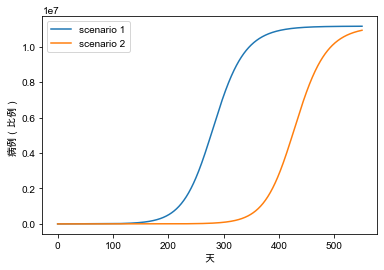

In [24]:
cases = [case * ν * pop_size for case in c_cases]
plot_cases(cases, labels)

This is the daily death rate:

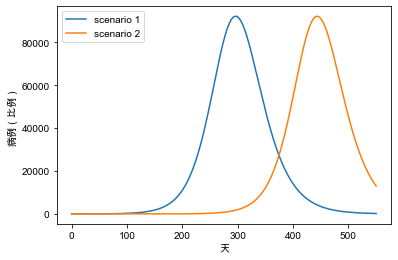

In [25]:
cases = [case * ν * γ * pop_size for case in i_cases]
plot_cases(cases, labels)

Pushing the peak of curve further into the future may reduce cumulative deaths
if a vaccine is found.